In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
Tiktok_data=pd.read_csv(r"C:\Users\User\Downloads\TikTok_Campaign_Dataset(new).csv")

In [21]:
Tiktok_data.head()

,lead_id,lead_date,campaign_name,channel,lead_source,age,age_group,gender,status,touchpoints,cost_per_lead,revenue_generated,days_to_conversion,product_purchased,season,month,year,quarter
0,L1000,4/15/2023,Summer_Blast,Instagram,Referral,18,18-24,Female,Qualified,9,48.53,0.00,0,NaN,Spring,April,2023,Q2
1,L1001,9/8/2024,Summer_Blast,Instagram,Organic,23,18-24,Female,Qualified,4,35.53,0.00,0,NaN,Fall,September,2024,Q3
2,L1002,6/13/2023,Spring_Promo,Google Search,Referral,26,25-34,Male,Converted,6,71.96,1750.42,28,Social Media Manager,Summer,June,2023,Q2
3,L1003,2/14/2023,Back_to_School,Instagram,Referral,46,45-54,Female,Nurturing,9,49.59,0.00,0,NaN,Winter,February,2023,Q1
4,L1004,1/6/2024,New_Year_Launch,Email,Referral,18,18-24,Male,Nurturing,12,23.55,0.00,0,NaN,Winter,January,2024,Q1


In [22]:
cp=Tiktok_data

In [23]:
#Data Normalization
cp['lead_date']=pd.to_datetime(cp['lead_date'])

In [24]:
cp.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lead_id             5000 non-null   str           
 1   lead_date           5000 non-null   datetime64[us]
 2   campaign_name       5000 non-null   str           
 3   channel             5000 non-null   str           
 4   lead_source         5000 non-null   str           
 5   age                 5000 non-null   int64         
 6   age_group           5000 non-null   str           
 7   gender              5000 non-null   str           
 8   status              5000 non-null   str           
 9   touchpoints         5000 non-null   int64         
 10  cost_per_lead       5000 non-null   float64       
 11  revenue_generated   5000 non-null   float64       
 12  days_to_conversion  5000 non-null   int64         
 13  product_purchased   1269 non-null   str           
 14  sea

In [25]:
cp.describe

<bound method NDFrame.describe of      lead_id  lead_date    campaign_name        channel lead_source  age  \
0      L1000 2023-04-15     Summer_Blast      Instagram    Referral   18   
1      L1001 2024-09-08     Summer_Blast      Instagram     Organic   23   
2      L1002 2023-06-13     Spring_Promo  Google Search    Referral   26   
3      L1003 2023-02-14   Back_to_School      Instagram    Referral   46   
4      L1004 2024-01-06  New_Year_Launch          Email    Referral   18   
...      ...        ...              ...            ...         ...  ...   
4995   L5995 2024-10-25  New_Year_Launch       Facebook      Direct   26   
4996   L5996 2023-10-24  New_Year_Launch      Instagram      Direct   42   
4997   L5997 2024-02-25     Summer_Blast        YouTube      Direct   52   
4998   L5998 2024-11-04     Black_Friday          Email    Referral   23   
4999   L5999 2024-05-10     Spring_Promo      Instagram     Organic   29   

     age_group  gender     status  touchpoints  cost_

In [26]:
#Replace bank cells

cp['days_to_conversion'] = cp['days_to_conversion'].fillna('0')

In [27]:
cp['days_to_conversion'].info()

<class 'pandas.Series'>
RangeIndex: 5000 entries, 0 to 4999
Series name: days_to_conversion
Non-Null Count  Dtype
--------------  -----
5000 non-null   int64
dtypes: int64(1)
memory usage: 39.2 KB


In [28]:
leads_distr=cp.groupby('channel')['lead_id'].count().reset_index()
leads_distr.columns=['Channel', 'Total Leads']
leads_distr=leads_distr.sort_values('Total Leads', ascending=False)
print(leads_distr.to_string(index=False))

      Channel  Total Leads
       TikTok          871
     Facebook          857
Google Search          857
    Instagram          849
      YouTube          810
        Email          756


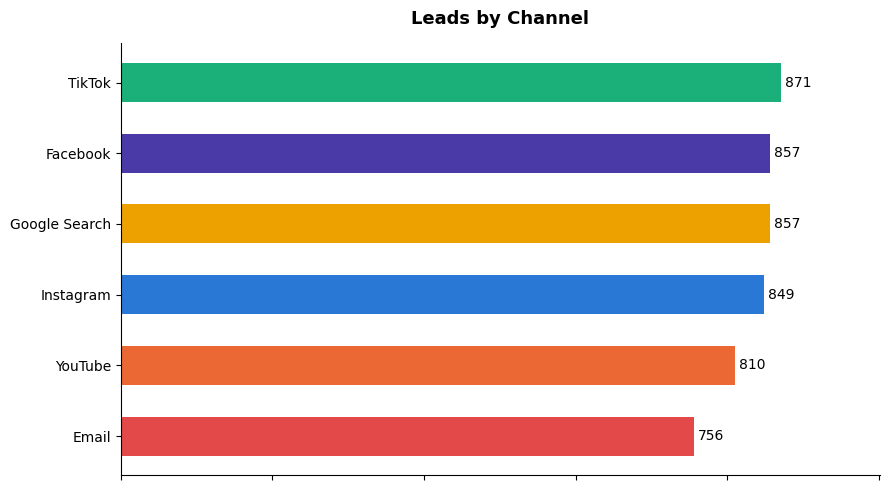

In [29]:
# Chart
colors = ['#1baf7a', '#4a3aa7', '#eda100', '#2a78d6', '#eb6834', '#e34948']

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(leads_distr['Channel'], leads_distr['Total Leads'],
               color=colors, height=0.55)

# Value labels
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}", va='center', fontsize=10)


ax.set_title('Leads by Channel', fontsize=13, fontweight='bold', pad=14)
ax.set_xlim(0, max(leads_distr['Total Leads']) * 1.15)
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='', alpha=0.4)
ax.set_xticklabels([]) 
plt.tight_layout()
plt.show()

In [30]:
leads_campn=cp.groupby('campaign_name')['lead_id'].count().reset_index()
leads_campn.columns=['campaign_name', 'Total Leads']
leads_campn.sort_values('Total Leads', ascending=False)
leads_campn.head().sort_values('Total Leads', ascending=False)

,campaign_name,Total Leads
0,Back_to_School,841
4,Summer_Blast,840
2,New_Year_Launch,837
1,Black_Friday,829
3,Spring_Promo,823


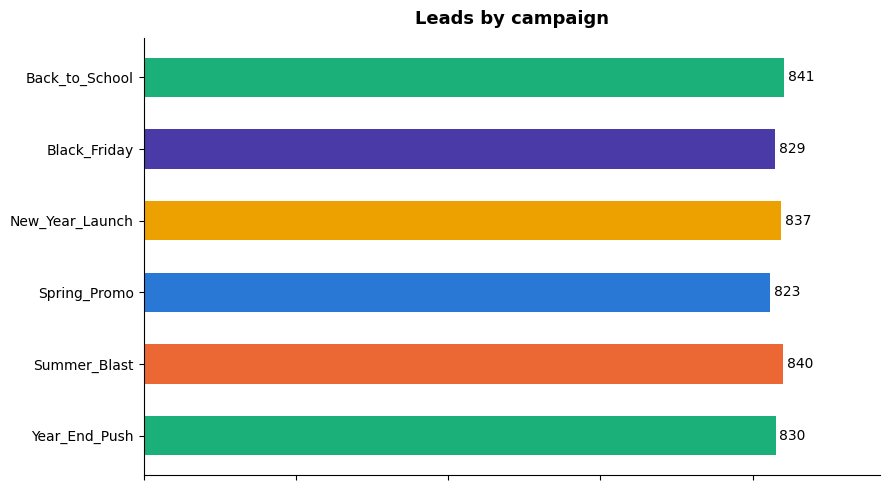

In [31]:
# Chart
colors = ['#1baf7a', '#4a3aa7', '#eda100', '#2a78d6', '#eb6834']

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(leads_campn['campaign_name'], leads_campn['Total Leads'],
               color=colors, height=0.55)

# Value labels
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}", va='center', fontsize=10)


ax.set_title('Leads by campaign', fontsize=13, fontweight='bold', pad=10)
ax.set_xlim(0, max(leads_campn['Total Leads']) * 1.15)
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='', alpha=0.4)
ax.set_xticklabels([]) 
plt.tight_layout()
plt.show()

In [32]:
cp.rename(columns={'revenue_generated': 'revenue'}, inplace=True)

### Quarterly revenue by campaign

In [156]:
cp.groupby('campaign_name')['revenue'].sum().round().sort_values(ascending=False)

campaign_name
Back_to_School     628387.0
Black_Friday       609588.0
Summer_Blast       600464.0
Year_End_Push      582373.0
Spring_Promo       560917.0
New_Year_Launch    461929.0
Name: revenue, dtype: float64

In [157]:
campaign_timing=cp.groupby(['campaign_name', 'quarter'])['revenue'].sum().unstack(fill_value=0)
campaign_timing['Total']=campaign_timing.sum(axis=1)
campaign_timing.loc['Total']=campaign_timing.sum()
campaign_timing

quarter,Q1,Q2,Q3,Q4,Total
campaign_name,,,,,
Back_to_School,154260.52,140071.83,172748.61,161306.44,628387.40
Black_Friday,154186.65,120231.65,171878.73,163290.98,609588.01
New_Year_Launch,98167.31,118408.08,126791.75,118561.53,461928.67
Spring_Promo,145043.38,127994.55,152015.33,135863.65,560916.91
Summer_Blast,154226.82,145378.19,146783.83,154074.99,600463.83
Year_End_Push,151464.31,172213.80,140168.47,118526.38,582372.96
Total,857348.99,824298.10,910386.72,851623.97,3443657.78


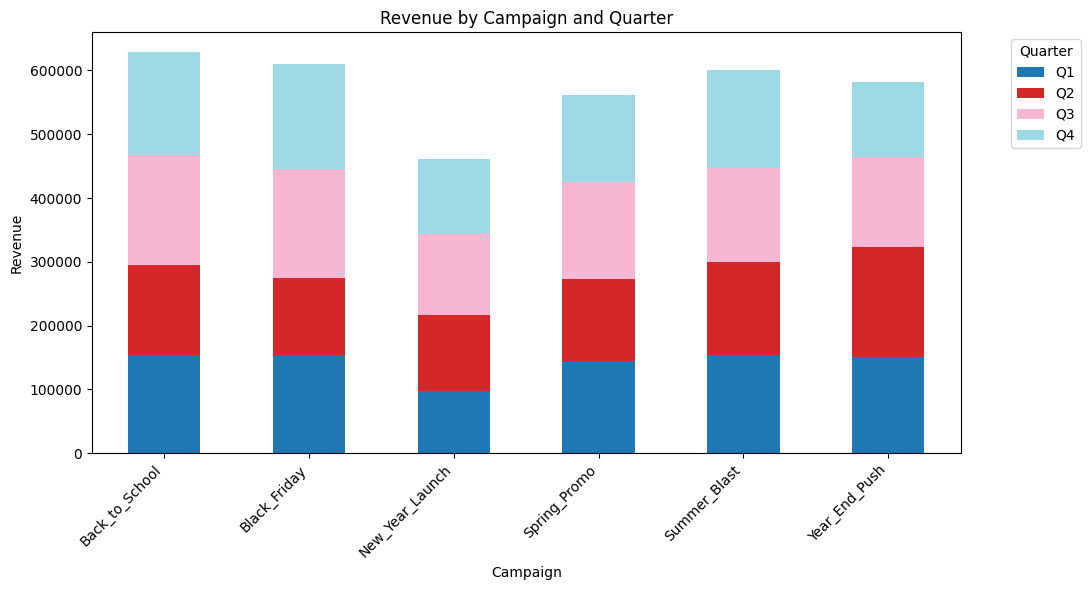

In [34]:


# Exclude the 'Total' row/column before plotting
plot_data = campaign_timing.drop('Total', axis=0).drop('Total', axis=1)

plot_data.plot(kind='bar', stacked=True, figsize=(11, 6), colormap='tab20')
plt.title('Revenue by Campaign and Quarter')
plt.xlabel('Campaign')
plt.ylabel('Revenue')
plt.legend(title='Quarter', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Revenue by lead source

In [53]:
source=cp.groupby('lead_source').agg(
    revenue = ('revenue', 'sum'),
    avg_cost_per_lead = ('cost_per_lead', 'mean'),
    Total_Leads = ('lead_id', 'count')
).reset_index()

source=source.sort_values('revenue', ascending=False)
source

,lead_source,revenue,avg_cost_per_lead,Total_Leads
2,Paid Ads,889357.46,46.935407,1230
0,Direct,868204.62,47.182565,1279
1,Organic,861861.87,46.749632,1224
3,Referral,824233.83,46.786638,1267


#### Lead source with the most lead lost

In [158]:
c=cp.groupby('lead_source').agg(
    Lost = ('status', lambda x: (x == 'Lost').sum()),
    Total_Leads = ('lead_id', 'count')
).reset_index()
c

,lead_source,Lost,Total_Leads
0,Direct,138,1279
1,Organic,133,1224
2,Paid Ads,115,1230
3,Referral,132,1267


#### Lead source with the most lead lost and least touchpoint band

In [140]:
s=cp.groupby(['touchpoint_band', 'lead_source']).agg(
    Lost = ('status', lambda x: (x == 'Lost').sum()),
    Total_Leads = ('lead_id', 'count')
).reset_index()
s

### campaign New year lunch, Direct lead_source with the most lead lost within touch point_band 1-3 is a warning that signals the ad-creative attracting unqualified clicks
### This can be corrected by tightening audience targeting or updating ad copy to filter for genuine intent before the click.

,touchpoint_band,lead_source,Lost,Total_Leads
0,1–3,Direct,41,317
1,1–3,Organic,36,299
2,1–3,Paid Ads,31,301
3,1–3,Referral,33,294
4,4–6,Direct,31,326
5,4–6,Organic,37,286
6,4–6,Paid Ads,30,316
7,4–6,Referral,27,311
8,7–9,Direct,33,323
9,7–9,Organic,32,308


#### Campaign with the most lead lost

In [151]:
c=cp.groupby('campaign_name').agg(
    Lost = ('status', lambda x: (x == 'Lost').sum()),
    Total_Leads = ('lead_id', 'count')
).reset_index()
c.sort_values('Lost', ascending=False)

,campaign_name,Lost,Total_Leads
2,New_Year_Launch,98,837
3,Spring_Promo,92,823
4,Summer_Blast,88,840
0,Back_to_School,86,841
1,Black_Friday,79,829
5,Year_End_Push,75,830


#### Campaigns with the most lead lost and least touchpoint band

In [149]:
c=cp.groupby(['touchpoint_band', 'campaign_name']).agg(
    Lost = ('status', lambda x: (x == 'Lost').sum()),
    Total_Leads = ('lead_id', 'count')
).reset_index()
c

### campaign New year lunch with the most lead lost within touch point_band 1-3 is a warning that signals the add attracting unqualified clicks
### This can be corrected by tightening audience targeting or updating ad copy to filter for genuine intent before the click.

,touchpoint_band,campaign_name,Lost,Total_Leads
0,1–3,Back_to_School,27,204
1,1–3,Black_Friday,22,194
2,1–3,New_Year_Launch,32,214
3,1–3,Spring_Promo,18,192
4,1–3,Summer_Blast,22,217
5,1–3,Year_End_Push,20,190
6,4–6,Back_to_School,21,203
7,4–6,Black_Friday,15,197
8,4–6,New_Year_Launch,21,219
9,4–6,Spring_Promo,23,218


#### Campaigns with the most lead lost 

In [150]:
c=cp.groupby('channel').agg(
    Lost = ('status', lambda x: (x == 'Lost').sum()),
    Total_Leads = ('lead_id', 'count')
).reset_index()
c.sort_values('Lost', ascending=False)

,channel,Lost,Total_Leads
4,TikTok,95,871
3,Instagram,92,849
1,Facebook,91,857
2,Google Search,84,857
5,YouTube,83,810
0,Email,73,756


#### Campaigns with the most lead lost and least touchpoint band

In [152]:
c=cp.groupby(['touchpoint_band', 'channel']).agg(
    Lost = ('status', lambda x: (x == 'Lost').sum()),
    Total_Leads = ('lead_id', 'count')
).reset_index()
c

### campaign New year lunch with the most lead lost within touch point_band 1-3 is a warning that signals the add attracting unqualified clicks
### This can be corrected by tightening audience targeting or updating ad copy to filter for genuine intent before the click.

,touchpoint_band,channel,Lost,Total_Leads
0,1–3,Email,25,182
1,1–3,Facebook,24,203
2,1–3,Google Search,21,208
3,1–3,Instagram,28,208
4,1–3,TikTok,20,203
5,1–3,YouTube,23,207
6,4–6,Email,21,197
7,4–6,Facebook,20,204
8,4–6,Google Search,21,206
9,4–6,Instagram,20,198


In [85]:
tik=cp

In [138]:
cp.columns

Index(['lead_id', 'lead_date', 'campaign_name', 'channel', 'lead_source',
       'age', 'age_group', 'gender', 'status', 'touchpoints', 'cost_per_lead',
       'revenue', 'days_to_conversion', 'product_purchased', 'season', 'month',
       'year', 'quarter', 'year_quarter', 'month_short', 'touchpoint_band'],
      dtype='str')

In [87]:
tik.rename(columns={'total_revenue':'revenue'}, inplace=True)

### Correlation test

In [88]:
# Adjust column names as needed
# Correlation Analysis
correlation = tik[['cost_per_lead', 'revenue']].corr().iloc[0,1]
print(f"Correlation between cost per lead and revenue per lead: {correlation:.4f}")

if correlation > 0.8:
    print("✅ Strong positive correlation")
elif correlation > 0.5:
    print("Moderate positive correlation")
else:
    print("Weak correlation")

#cost_per_lead and total_revenue don't move together in any linear way in your data.
#Spending more (or less) per lead doesn't predict higher or lower total revenue — at least not linearly, and not in this dataset.

Correlation between cost per lead and revenue per lead: -0.0058
Weak correlation


In [89]:
for col in ['cost_per_lead', 'revenue']:
    Q1 = tik[col].quantile(0.25)
    Q3 = tik[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = tik[(tik[col] < lower) | (tik[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (bounds: {lower:.2f} to {upper:.2f})")

cost_per_lead: 0 outliers (bounds: 4.67 to 90.64)
revenue: 977 outliers (bounds: -873.29 to 1455.49)


In [90]:
from scipy import stats
import numpy as np

for col in ['cost_per_lead', 'revenue']:
    z_scores = np.abs(stats.zscore(tik[col].dropna()))
    outliers = tik.loc[tik[col].dropna().index][z_scores > 3]
    print(f"{col}: {len(outliers)} outliers")

cost_per_lead: 0 outliers
revenue: 74 outliers


### Total conversion rate

In [92]:
total_leads=cp['lead_id'].count()
conversions=(cp['status'] == 'Converted').sum()
overall_conversion_rate = (conversions/total_leads * 100).round(2)
print(f'overall conversion rate: {overall_conversion_rate:.2f}%')

overall conversion rate: 25.38%


### Conversion rate by channel

In [93]:
conv_by_channel = cp.groupby('channel').agg(
    Total_Leads   = ('lead_id',  'count'),
    Conversions   = ('status', lambda x: (x == 'Converted').sum())
).reset_index()

conv_by_channel['Conversion_Rate (%)'] = (
    conv_by_channel['Conversions'] / conv_by_channel['Total_Leads'] * 100
).round(2)


print(conv_by_channel.to_string(index=False))

      channel  Total_Leads  Conversions  Conversion_Rate (%)
        Email          756          193                25.53
     Facebook          857          217                25.32
Google Search          857          212                24.74
    Instagram          849          219                25.80
       TikTok          871          218                25.03
      YouTube          810          210                25.93


### Conversion rate by campaigns


In [203]:
conv_by_campaign = cp.groupby('campaign_name').agg(
    Total_Leads   = ('lead_id',  'count'),
    Conversions   = ('status', lambda x: (x == 'Converted').sum())
).reset_index()

conv_by_campaign['Conversion_Rate (%)'] = (
    conv_by_campaign['Conversions'] / conv_by_campaign['Total_Leads'] * 100
).round(2)

conv_by_campaign.sort_values('Conversion_Rate (%)', ascending=False)


,campaign_name,Total_Leads,Conversions,Conversion_Rate (%)
1,Black_Friday,829,230,27.74
0,Back_to_School,841,226,26.87
4,Summer_Blast,840,225,26.79
5,Year_End_Push,830,209,25.18
3,Spring_Promo,823,194,23.57
2,New_Year_Launch,837,185,22.10


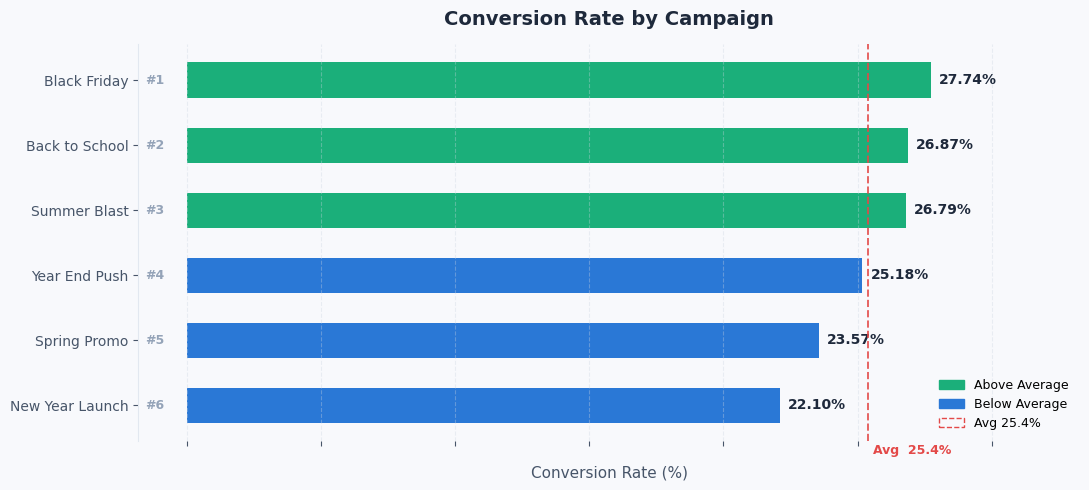

In [197]:
# ── Chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#f8f9fc')
ax.set_facecolor('#f8f9fc')

campaigns  = conv_by_campaign['campaign_name'].str.replace('_', ' ')
conv_rates = conv_by_campaign['Conversion_Rate (%)'].values
avg        = conv_rates.mean()

# Color bars — highlight above/below average
colors = ['#1baf7a' if v >= avg else '#2a78d6' for v in conv_rates]

bars = ax.barh(campaigns[::-1], conv_rates[::-1],
               color=colors[::-1], height=0.55, edgecolor='none')

# Value labels
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.2f}%",
            va='center', fontsize=10, fontweight='bold', color='#1e293b')

# Average reference line
ax.axvline(avg, color='#e34948', linewidth=1.4,
           linestyle='--', alpha=0.85, zorder=5)
ax.text(avg + 0.2, -0.6, f'Avg  {avg:.1f}%',
        color='#e34948', fontsize=9, fontweight='bold', va='top')

# Rank badges on the left
for i, (bar, rank) in enumerate(zip(bars, range(len(bars), 0, -1))):
    ax.text(-1.2, bar.get_y() + bar.get_height() / 2,
            f"#{rank}", va='center', ha='center',
            fontsize=9, fontweight='bold', color='#94a3b8')

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='#1baf7a', label='Above Average'),
          Patch(color='#2a78d6', label='Below Average'),
          Patch(color='#e34948', label=f'Avg {avg:.1f}%', linestyle='--', fill=False)]
ax.legend(handles=legend, fontsize=9, frameon=False,
          loc='lower right')

# Formatting
ax.set_xlabel('Conversion Rate (%)', fontsize=11, color='#475569', labelpad=10)
ax.set_title('Conversion Rate by Campaign',
             fontsize=14, fontweight='bold', pad=14, color='#1e293b')
ax.set_xlim(-1.8, max(conv_rates) * 1.20)
ax.set_xticklabels([])
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines['left'].set_color('#e2e8f0')
ax.grid(axis='x', linestyle='--', alpha=0.35, color='#cbd5e1')
ax.tick_params(colors='#475569')

plt.tight_layout()
plt.show()

### Conversion rate by lead source

In [94]:

conv_by_lead_source = cp.groupby('lead_source').agg(
    Total_Leads   = ('lead_id',  'count'),
    Conversions   = ('status', lambda x: (x == 'Converted').sum())
).reset_index()

conv_by_lead_source['Conversion_Rate (%)'] = (
    conv_by_lead_source['Conversions'] / conv_by_lead_source['Total_Leads'] * 100
).round(2)

conv_by_lead_source=conv_by_lead_source.sort_values('Conversion_Rate (%)', ascending=False)

print(conv_by_lead_source.to_string(index=False))

lead_source  Total_Leads  Conversions  Conversion_Rate (%)
   Paid Ads         1230          330                26.83
    Organic         1224          314                25.65
     Direct         1279          315                24.63
   Referral         1267          310                24.47


In [95]:
total_conversions=(cp['status'] == 'Converted').sum()
print(total_conversions)

1269


### Leads Growth Rate YoY

In [96]:


# ─────────────────────────────────────────────
# 1. YEAR-OVER-YEAR (YoY) LEAD GROWTH RATE
# ─────────────────────────────────────────────
yoy = cp.groupby('year')['lead_id'].count().reset_index()
yoy.columns = ['Year', 'Total_Leads']
yoy['YoY_Growth (%)'] = yoy['Total_Leads'].pct_change() * 100
yoy['YoY_Growth (%)'] = yoy['YoY_Growth (%)'].round(2)


print("   YEAR-OVER-YEAR (YoY) LEAD GROWTH")

print(yoy.to_string(index=False))

   YEAR-OVER-YEAR (YoY) LEAD GROWTH
 Year  Total_Leads  YoY_Growth (%)
 2023         2411             NaN
 2024         2589            7.38


### Leads Growth Rate QoQ

In [97]:
cp['year_quarter'] = cp['lead_date'].dt.to_period('Q').astype(str)

qoq = cp.groupby('year_quarter')['lead_id'].count().reset_index()
qoq.columns = ['year_quarter', 'Total_Leads']
qoq['QoQ_Growth (%)'] = qoq['Total_Leads'].pct_change() * 100
qoq['QoQ_Growth (%)'] = qoq['QoQ_Growth (%)'].round(2)


print("   Quarter-OVER-Quarter (YoY) LEAD GROWTH")

print(qoq.to_string(index=False))

   Quarter-OVER-Quarter (YoY) LEAD GROWTH
year_quarter  Total_Leads  QoQ_Growth (%)
      2023Q1          573             NaN
      2023Q2          615            7.33
      2023Q3          613           -0.33
      2023Q4          610           -0.49
      2024Q1          658            7.87
      2024Q2          629           -4.41
      2024Q3          650            3.34
      2024Q4          652            0.31


C:\Users\User\AppData\Local\Temp\ipykernel_21272\2385876640.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(yoy['Year'].astype(str), fontsize=11)
C:\Users\User\AppData\Local\Temp\ipykernel_21272\2385876640.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


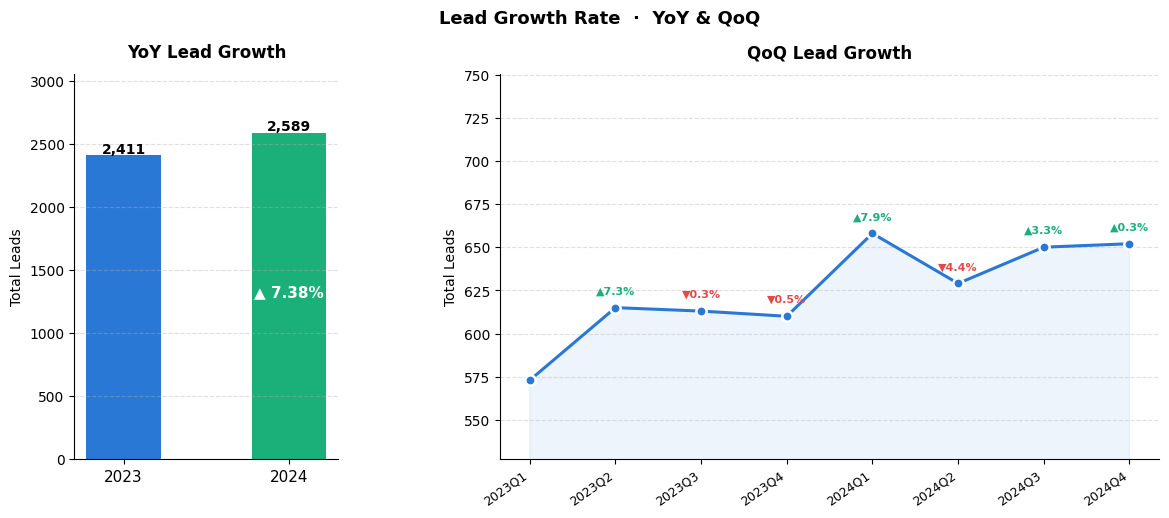

In [98]:
# ─────────────────────────────────────────────
# 3. CHART — YoY and QoQ side by side
# ─────────────────────────────────────────────
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 2.5], wspace=0.35)

# ── YoY bar ──
ax1 = fig.add_subplot(gs[0])
colors_yoy = ['#2a78d6', '#1baf7a']
bars = ax1.bar(yoy['Year'].astype(str), yoy['Total_Leads'],
               color=colors_yoy, width=0.45, edgecolor='none')
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 18,
             f"{int(bar.get_height()):,}", ha='center', fontsize=10, fontweight='bold')
ax1.set_title('YoY Lead Growth', fontsize=12, fontweight='bold', pad=12)
ax1.set_ylabel('Total Leads', fontsize=10)
ax1.set_ylim(0, max(yoy['Total_Leads']) * 1.18)
ax1.set_xticklabels(yoy['Year'].astype(str), fontsize=11)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.text(1, yoy['Total_Leads'].iloc[1] / 2,
         '▲ 7.38%', ha='center', color='white', fontsize=11, fontweight='bold')

# ── QoQ line ──
ax2 = fig.add_subplot(gs[1])
qoq_vals   = qoq['Total_Leads'].values
qoq_labels = qoq['year_quarter'].values
x = range(len(qoq_labels))

ax2.fill_between(x, qoq_vals, alpha=0.08, color='#2a78d6')
ax2.plot(x, qoq_vals, color='#2a78d6', linewidth=2.2, zorder=3)
ax2.scatter(x, qoq_vals, color='#2a78d6', s=55, zorder=4,
            edgecolors='white', linewidths=1.8)

# Growth rate labels above each point
for i, (val, gr) in enumerate(zip(qoq_vals, qoq['QoQ_Growth (%)'])):
    if pd.notna(gr):
        color  = '#1baf7a' if gr >= 0 else '#e34948'
        symbol = '▲' if gr >= 0 else '▼'
        ax2.text(i, val + 8, f"{symbol}{abs(gr):.1f}%",
                 ha='center', fontsize=8, color=color, fontweight='bold')

ax2.set_xticks(list(x))
ax2.set_xticklabels(qoq_labels, rotation=35, ha='right', fontsize=9)
ax2.set_title('QoQ Lead Growth', fontsize=12, fontweight='bold', pad=12)
ax2.set_ylabel('Total Leads', fontsize=10)
ax2.set_ylim(min(qoq_vals) * 0.92, max(qoq_vals) * 1.14)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Lead Growth Rate  ·  YoY & QoQ', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [99]:
total_revenue=cp['revenue'].sum().round(2)
print(f"total revenue")
print(total_revenue)

total revenue
3443657.78


In [100]:
total_costs=cp['cost_per_lead'].sum().round(2)
print(f'total_cost')
print(total_costs)

total_cost
234577.27


In [101]:

profit=total_revenue-total_costs
print(f'profit')
print(profit)

profit
3209080.51


In [102]:
profit_margin = ((profit/total_revenue) * 100).round(2)
print(f'profit_margin%')
print(profit_margin)

profit_margin%
93.19


### Rate of Leads Lost

In [103]:
status_table = cp.groupby('status')['lead_id'].count().reset_index()
status_table.columns = ['status', 'count']
status_table['rate (%)'] = (status_table['count'] / status_table['count'].sum() * 100).round(2)

print(status_table.to_string())

      status  count  rate (%)
0  Converted   1269     25.38
1       Lost    518     10.36
2   New Lead   1003     20.06
3  Nurturing   1232     24.64
4  Qualified    978     19.56


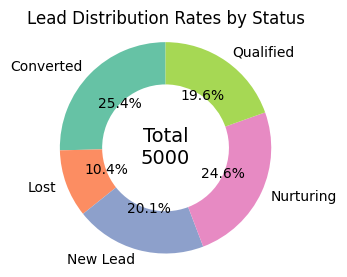

In [198]:

plt.figure(figsize=(3, 3))
plt.pie(
    status_table['count'],
    labels=status_table['status'],
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set2.colors,
    wedgeprops=dict(width=0.4)
)
plt.title('Lead Distribution Rates by Status')
plt.gca().text(0, 0, f"Total\n{status_table['count'].sum()}", ha='center', va='center', fontsize=14)
plt.axis('equal')
plt.show()

#### Most profitable SKUs

In [105]:
most_profitable_sku=cp.groupby('campaign_name').agg(
    product_count = ('product_purchased', 'count'),
    leads = ('lead_id', 'count'),
    revenue = ('revenue', 'sum')
).sort_values('revenue', ascending=False).reset_index()

most_profitable_sku

,campaign_name,product_count,leads,revenue
0,Back_to_School,226,841,628387.40
1,Black_Friday,230,829,609588.01
2,Summer_Blast,225,840,600463.83
3,Year_End_Push,209,830,582372.96
4,Spring_Promo,194,823,560916.91
5,New_Year_Launch,185,837,461928.67


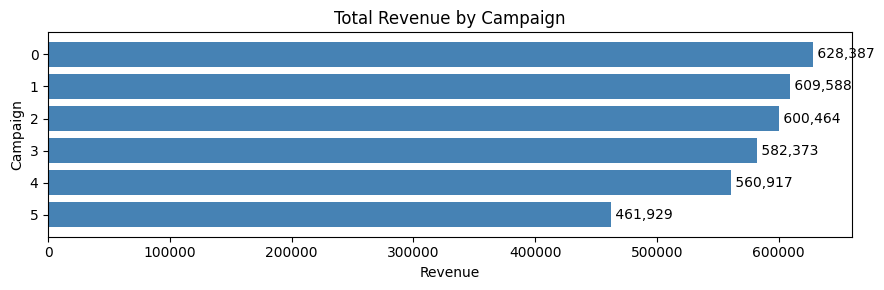

In [106]:

plt.figure(figsize=(9, 3))
plt.barh(most_profitable_sku.index, most_profitable_sku['revenue'], color='steelblue')
plt.title('Total Revenue by Campaign')
plt.xlabel('Revenue')
plt.ylabel('Campaign')
plt.gca().invert_yaxis()  # highest revenue at the top

for i, rev in enumerate(most_profitable_sku['revenue']):
    plt.text(rev, i, f' {rev:,.0f}', va='center')
ax.set_xticklabels([])
plt.tight_layout()
plt.show()

### Revenue distribution by products

In [107]:
product_revenue=cp.groupby('product_purchased')['revenue'].sum().sort_values(ascending=False)
product_revenue

product_purchased
CRM Integration          726203.26
SEO Pro                  718320.74
Social Media Manager     707559.21
Brand Analytics Suite    685092.63
Digital Ads Package      606481.94
Name: revenue, dtype: float64

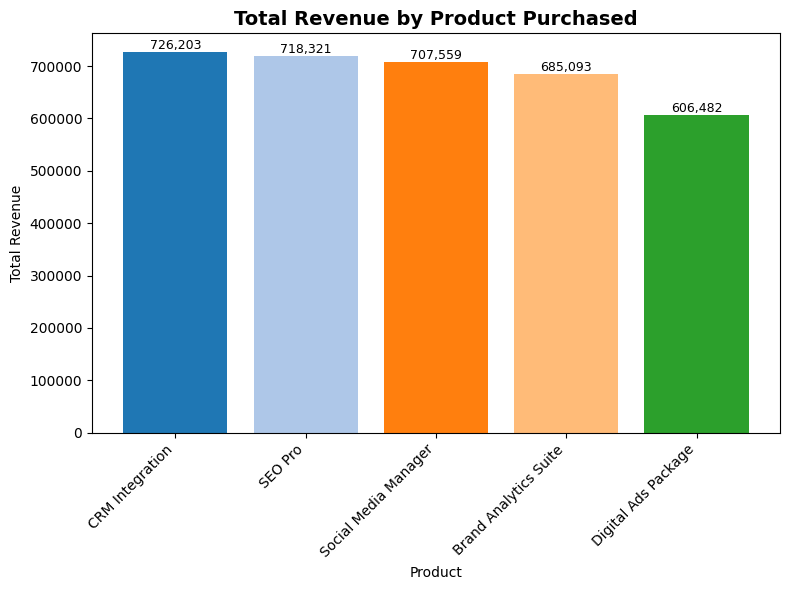

In [170]:


# Bar chart with a different color per bar
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab20.colors  # up to 20 distinct colors
bars = ax.bar(product_revenue.index, product_revenue.values,
               color=colors[:len(product_revenue)])

ax.set_title('Total Revenue by Product Purchased', fontsize=14, fontweight='bold')
ax.set_xlabel('Product')
ax.set_ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')

# add value labels on top of each bar
for bar, value in zip(bars, product_revenue.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{value:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#### Conversion rate by age_group

In [108]:
conv_rate=cp.groupby('age_group').agg(
    total_leads = ('lead_id', 'count'),
    conversion =  ('status', lambda x: (x == 'Converted').sum())
    ).reset_index()

conv_rate['conv_rate%']=((conv_rate['conversion']/conv_rate['total_leads']) * 100).round(2)
conv_rate.sort_values('conv_rate%', ascending=False)

,age_group,total_leads,conversion,conv_rate%
4,55+,1001,264,26.37
1,25-34,1011,263,26.01
2,35-44,972,248,25.51
0,18-24,979,244,24.92
3,45-54,1037,250,24.11


  age_group  total_leads  conversion  conv_rate%
4       55+         1001         264       26.37
1     25-34         1011         263       26.01
2     35-44          972         248       25.51
0     18-24          979         244       24.92
3     45-54         1037         250       24.11


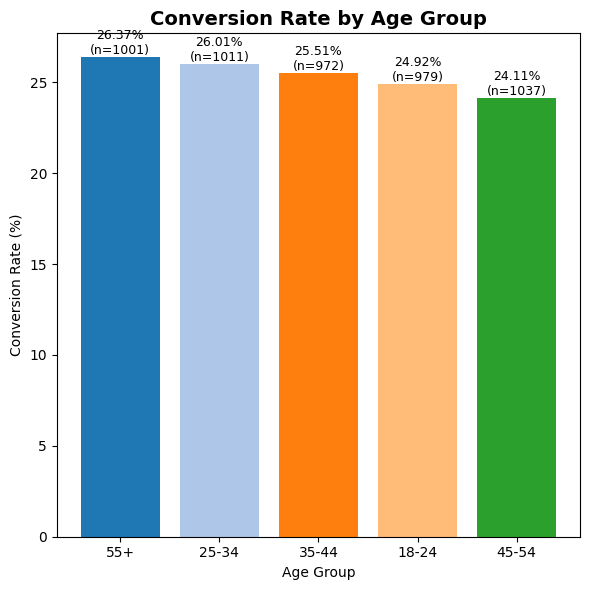

In [172]:
import matplotlib.pyplot as plt

conv_rate = cp.groupby('age_group').agg(
    total_leads=('lead_id', 'count'),
    conversion=('status', lambda x: (x == 'Converted').sum())
    ).reset_index()
conv_rate['conv_rate%'] = ((conv_rate['conversion'] / conv_rate['total_leads']) * 100).round(2)
conv_rate = conv_rate.sort_values('conv_rate%', ascending=False)
print(conv_rate.to_string())

# Bar chart with a different color per age group
fig, ax = plt.subplots(figsize=(6, 6))
colors = plt.cm.tab20.colors
bars = ax.bar(conv_rate['age_group'], conv_rate['conv_rate%'],
               color=colors[:len(conv_rate)])

ax.set_title('Conversion Rate by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Conversion Rate (%)')
plt.xticks(rotation=0)

# add % labels on top of each bar
for bar, rate, total in zip(bars, conv_rate['conv_rate%'], conv_rate['total_leads']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{rate}%\n(n={total})', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Gender split by age group

In [110]:


age_gender = cp.groupby(['age_group', 'gender'])['lead_id'].count().unstack(fill_value=0)
age_gender['Total'] = age_gender.sum(axis=1)
age_gender['Female_%'] = (age_gender['Female'] / age_gender['Total'] * 100).round(2)
age_gender['Male_%']   = (age_gender['Male']   / age_gender['Total'] * 100).round(2)
age_gender = age_gender.sort_values('Total', ascending=False)

print(age_gender.to_string())

gender     Female  Male  Total  Female_%  Male_%
age_group                                       
45-54         525   512   1037     50.63   49.37
25-34         528   483   1011     52.23   47.77
55+           506   495   1001     50.55   49.45
18-24         467   512    979     47.70   52.30
35-44         475   497    972     48.87   51.13


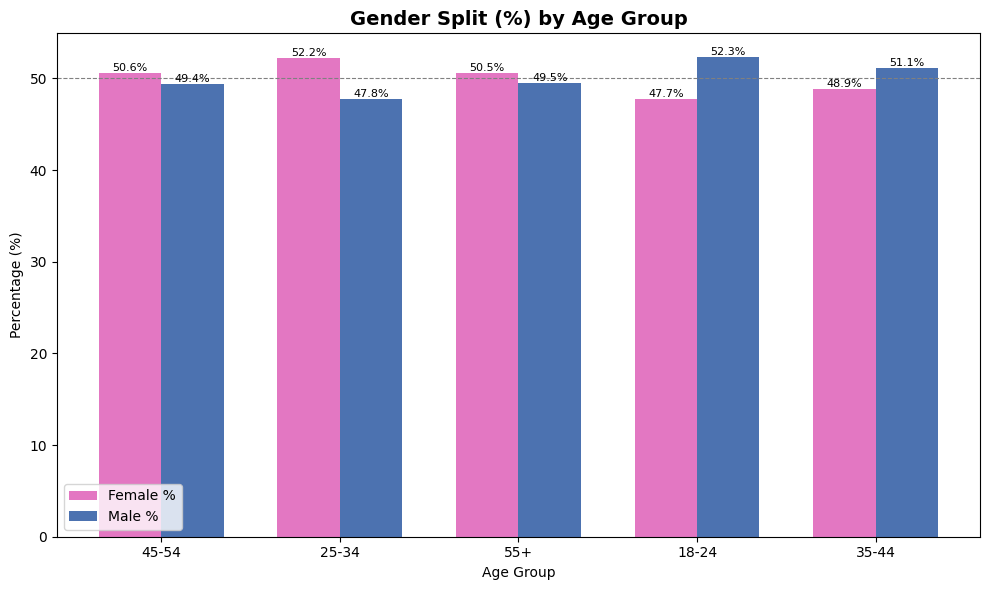

In [181]:
fig, ax = plt.subplots(figsize=(10, 6))
bars_f = ax.bar(x - width/2, age_gender['Female_%'], width, label='Female %', color='#E377C2')
bars_m = ax.bar(x + width/2, age_gender['Male_%'], width, label='Male %', color='#4C72B0')

ax.set_title('Gender Split (%) by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Percentage (%)')
ax.set_xticks(x)
ax.set_xticklabels(age_gender.index)
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)  # reference line at 50/50
ax.legend()

for bars in [bars_f, bars_m]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### Revenue Distribution Gender

In [111]:
# Revenue Distribution Gender

cp.groupby('gender').agg(
     conversion = ('status', lambda x: (x == 'Converted').sum()),
     
     revenue = ('revenue', 'sum')
)


,conversion,revenue
gender,,
Female,649,1752940.70
Male,620,1690717.08


   gender  conversion     revenue
0  Female         649  1752940.70
1    Male         620  1690717.08


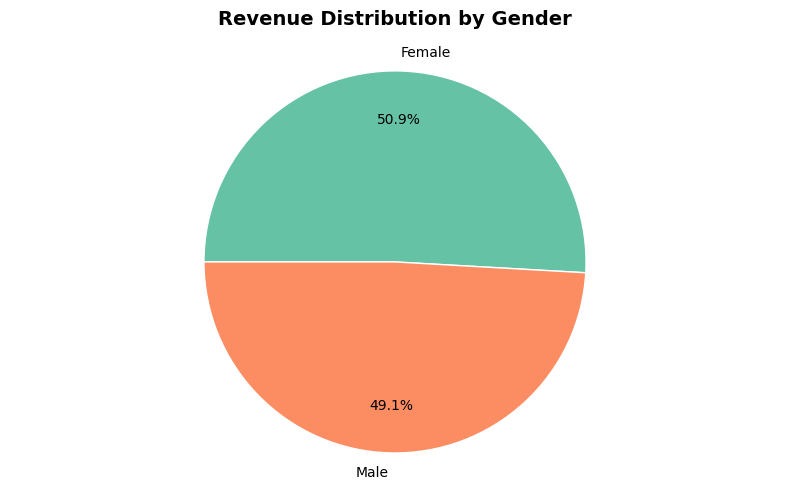

In [179]:
import matplotlib.pyplot as plt
import numpy as np

gender_summary = cp.groupby('gender').agg(
    conversion=('status', lambda x: (x == 'Converted').sum()),
    revenue=('revenue', 'sum')
).reset_index()

print(gender_summary.to_string())

# Semi-circular pie chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.Set2.colors

wedges, texts, autotexts = ax.pie(
    gender_summary['revenue'],
    labels=gender_summary['gender'],
    autopct='%1.1f%%',
    startangle=180,
    counterclock=False,
    colors=colors[:len(gender_summary)],
    wedgeprops=dict(width=1, edgecolor='white'),
    pctdistance=0.75
)

# cut the pie in half by masking the bottom
ax.set_ylim(0, 1)
ax.set_title('Revenue Distribution by Gender', fontsize=14, fontweight='bold', pad=20)
ax.axis('equal')

plt.tight_layout()
plt.show()

### Monthly lead trend

In [112]:
lead_trend=cp.groupby('month')['lead_id'].count().reset_index()
lead_trend.columns=['Month', 'Leads']

lead_trend


,Month,Leads
0,April,405
1,August,413
2,December,415
3,February,420
4,January,400
5,July,423
6,June,396
7,March,411
8,May,443
9,November,410


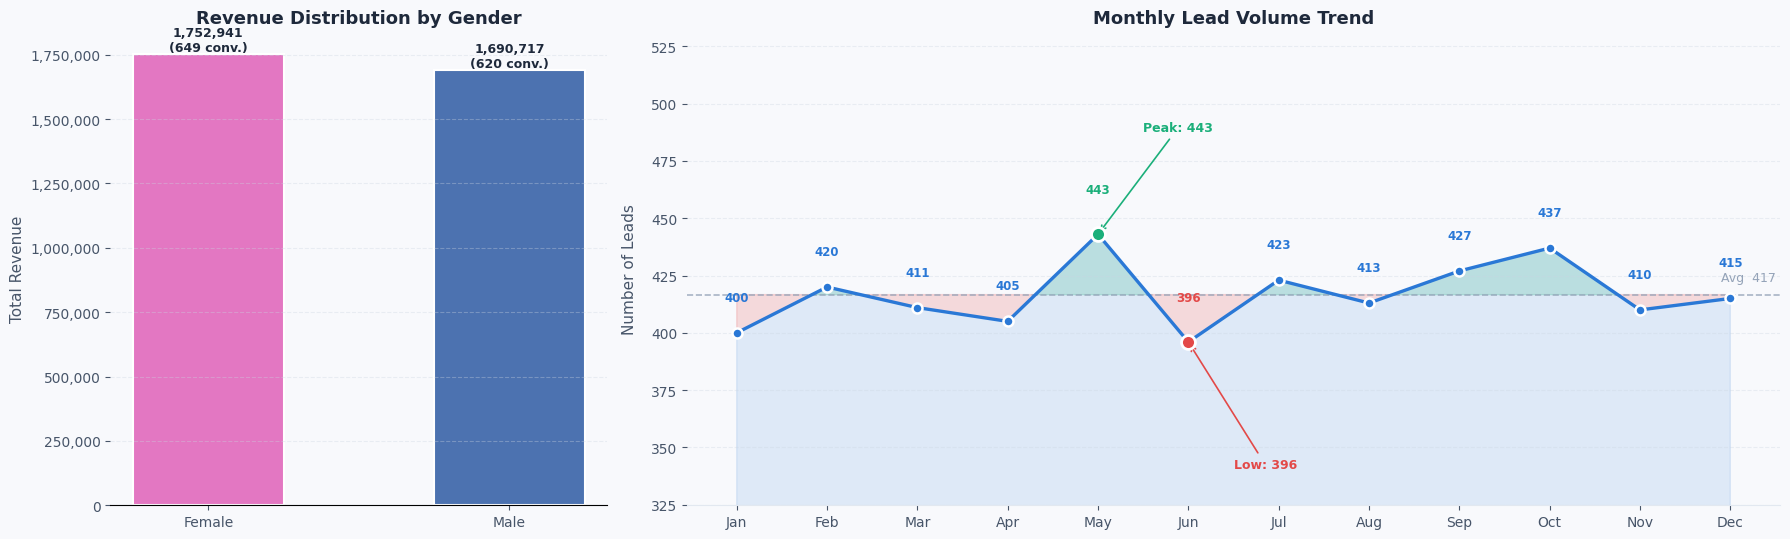

In [187]:

import matplotlib.ticker as mticker

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5.5),
                                 gridspec_kw={'width_ratios': [1, 2.2]})
fig.patch.set_facecolor('#f8f9fc')

# ── Chart 1: Revenue & Conversion by Gender (Bar Chart) ─────────
gender_summary = cp.groupby('gender').agg(
    conversion=('status', lambda x: (x == 'Converted').sum()),
    revenue=('revenue', 'sum')
).reset_index()

ax1.set_facecolor('#f8f9fc')
colors = ['#E377C2', '#4C72B0']  # Female, Male
bars = ax1.bar(gender_summary['gender'], gender_summary['revenue'],
               color=colors[:len(gender_summary)], width=0.5,
               edgecolor='white', linewidth=1.5)

ax1.set_title('Revenue Distribution by Gender', fontsize=13, fontweight='bold', color='#1e293b')
ax1.set_ylabel('Total Revenue', fontsize=11, color='#475569')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax1.spines[['top', 'right', 'left']].set_visible(False)
ax1.grid(axis='y', linestyle='--', alpha=0.35, color='#cbd5e1')
ax1.tick_params(axis='both', colors='#475569')

for bar, rev, conv in zip(bars, gender_summary['revenue'], gender_summary['conversion']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
              f'{rev:,.0f}\n({conv} conv.)', ha='center', va='bottom',
              fontsize=9, fontweight='bold', color='#1e293b')

# ── Chart 2: Monthly Lead Volume Trend ────────────────────────────
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
lead_trend = cp.groupby('month')['lead_id'].count().reset_index()
lead_trend.columns = ['Month', 'Leads']
lead_trend['Month'] = pd.Categorical(lead_trend['Month'],
                                     categories=month_order, ordered=True)
lead_trend = lead_trend.sort_values('Month').reset_index(drop=True)

ax2.set_facecolor('#f8f9fc')
x    = range(len(lead_trend))
y    = lead_trend['Leads'].values
avg  = y.mean()
xmax = lead_trend['Leads'].idxmax()
xmin = lead_trend['Leads'].idxmin()

ax2.fill_between(x, y, alpha=0.12, color='#2a78d6')
ax2.fill_between(x, y, avg, where=(y >= avg), alpha=0.18, color='#1baf7a', interpolate=True)
ax2.fill_between(x, y, avg, where=(y <  avg), alpha=0.18, color='#e34948', interpolate=True)
ax2.plot(x, y, color='#2a78d6', linewidth=2.4, zorder=3, solid_capstyle='round')
ax2.scatter(x, y, color='#2a78d6', s=52, zorder=5, edgecolors='white', linewidths=1.8)
ax2.scatter(xmax, y[xmax], color='#1baf7a', s=100, zorder=6, edgecolors='white', linewidths=2)
ax2.scatter(xmin, y[xmin], color='#e34948', s=100, zorder=6, edgecolors='white', linewidths=2)

for i, val in enumerate(y):
    offset = 14 if i not in [xmax, xmin] else 18
    color  = '#2a78d6'
    if i == xmax: color = '#1baf7a'
    if i == xmin: color = '#e34948'
    ax2.text(i, val + offset, f"{val:,}", ha='center', fontsize=8.5, color=color, fontweight='bold')

ax2.axhline(avg, color='#94a3b8', linewidth=1.2, linestyle='--', alpha=0.8, zorder=2)
ax2.text(len(x) - 0.5, avg + 6, f'Avg  {avg:.0f}', color='#94a3b8', fontsize=9, ha='right', fontweight='500')

ax2.annotate(f"Peak: {y[xmax]:,}", xy=(xmax, y[xmax]), xytext=(xmax + 0.5, y[xmax] + 45),
             fontsize=9, color='#1baf7a', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#1baf7a', lw=1.2))
ax2.annotate(f"Low: {y[xmin]:,}", xy=(xmin, y[xmin]), xytext=(xmin + 0.5, y[xmin] - 55),
             fontsize=9, color='#e34948', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#e34948', lw=1.2))

ax2.set_xticks(list(x))
ax2.set_xticklabels([m[:3] for m in lead_trend['Month']], fontsize=10, color='#475569')
ax2.set_ylabel('Number of Leads', fontsize=11, color='#475569', labelpad=10)
ax2.set_ylim(min(y) * 0.82, max(y) * 1.20)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))
ax2.tick_params(axis='both', colors='#475569')
ax2.spines[['top','right','left']].set_visible(False)
ax2.spines['bottom'].set_color('#e2e8f0')
ax2.grid(axis='y', linestyle='--', alpha=0.35, color='#cbd5e1')
ax2.set_title('Monthly Lead Volume Trend', fontsize=13, fontweight='bold', color='#1e293b')

plt.tight_layout()
plt.show()

#### Quarterly trend(Lead)

In [188]:
quarterly_trend=cp.groupby('quarter')['lead_id'].count().reset_index()
quarterly_trend.columns=['Quarter', 'Leads']

quarterly_trend


,Quarter,Leads
0,Q1,1231
1,Q2,1244
2,Q3,1263
3,Q4,1262


#### Average cost per lead

In [201]:
avg_cost_per_lead=cp['cost_per_lead'].mean().round(2)
print(f'avg_cost_per_lead: {avg_cost_per_lead}')


avg_cost_per_lead: 46.92


#### Seasonal conversion rate(quarter)

In [202]:
quarterly_rate=cp.groupby('quarter').agg(
  revenue =  ('revenue', 'sum'),
    total_leads =('lead_id', 'count'),
conversion=  ('status', lambda x: (x == 'Converted').sum())
).reset_index()

quarterly_rate['quarterly_rate%']=(monthly_rate['conversion']/monthly_rate['total_leads']) * 100
quarterly_rate.round(2)

# High conversation rate, but low revenue? leads are probably purchasing cheaper products

,quarter,revenue,total_leads,conversion,quarterly_rate%
0,Q1,857348.99,1231,319,25.91
1,Q2,824298.10,1244,298,23.95
2,Q3,910386.72,1263,330,26.13
3,Q4,851623.97,1262,322,25.52


#### Seasonal conversion rate(year)

In [116]:
yearly_rate=cp.groupby('year').agg(
  revenue =  ('revenue', 'sum'),
    total_leads =('lead_id', 'count'),
conversion=  ('status', lambda x: (x == 'Converted').sum())
).reset_index()

yearly_rate['yearly_rate%']=(yearly_rate['conversion']/yearly_rate['total_leads']) * 100
yearly_rate.round(2)

# High conversation rate, but low revenue? leads are probably purchasing cheaper products

,year,revenue,total_leads,conversion,yearly_rate%
0,2023,1647085.32,2411,616,25.55
1,2024,1796572.46,2589,653,25.22


### age distribution by touchpoints

In [119]:
cp['month_short'] = cp['lead_date'].dt.strftime('%b')


### Conversions per touchpoints_band

In [191]:
## Touchpoints converted

import pandas as pd



# ── Group touchpoints into bands ──────────────────────────────
bins   = [0, 3, 6, 9, 12]
labels = ['1–3', '4–6', '7–9', '10–12']

cp['touchpoint_band'] = pd.cut(cp['touchpoints'],
                                bins=bins,
                                labels=labels,
                                right=True)

# ── Summary table ─────────────────────────────────────────────
band_summary = cp.groupby('touchpoint_band', observed=True).agg(
    Total_Leads   = ('lead_id', 'count'),
    Conversions   = ('status', lambda x: (x == 'Converted').sum()),
    Avg_Revenue   = ('revenue', 'mean'),
    Total_Revenue = ('revenue', 'sum')
).reset_index()

band_summary['Conversion_Rate (%)'] = (
    band_summary['Conversions'] / band_summary['Total_Leads'] * 100
).round(2)
band_summary['Avg_Revenue']   = band_summary['Avg_Revenue'].round(2)
band_summary['Total_Revenue'] = band_summary['Total_Revenue'].round(2)

print(band_summary.to_string(index=False))

touchpoint_band  Total_Leads  Conversions  Avg_Revenue  Total_Revenue  Conversion_Rate (%)
            1–3         1211          321       724.18      876981.67                26.51
            4–6         1239          311       659.10      816628.52                25.10
            7–9         1254          297       669.56      839625.55                23.68
          10–12         1296          340       702.49      910422.04                26.23


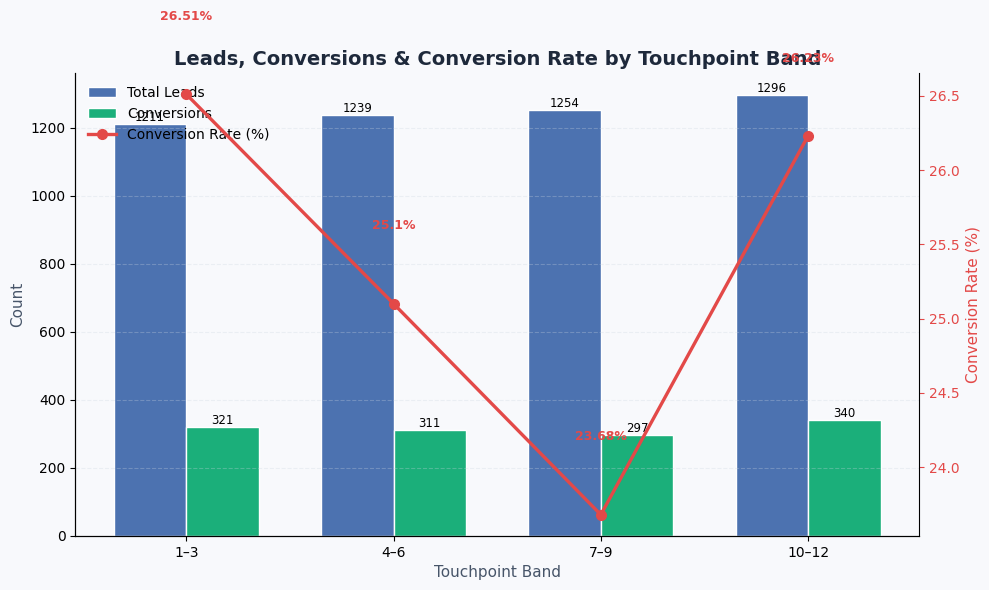

In [217]:

fig, ax1 = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f8f9fc')
ax1.set_facecolor('#f8f9fc')

x = range(len(band_summary))
width = 0.35

bars1 = ax1.bar([i - width/2 for i in x], band_summary['Total_Leads'], width,
                 label='Total Leads', color='#4C72B0', edgecolor='white')
bars2 = ax1.bar([i + width/2 for i in x], band_summary['Conversions'], width,
                 label='Conversions', color='#1baf7a', edgecolor='white')

ax1.set_xlabel('Touchpoint Band', fontsize=11, color='#475569')
ax1.set_ylabel('Count', fontsize=11, color='#475569')
ax1.set_xticks(list(x))
ax1.set_xticklabels(band_summary['touchpoint_band'], fontsize=10)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', linestyle='--', alpha=0.3, color='#cbd5e1')

for bars in [bars1, bars2]:
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                  f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=8.5)

# secondary axis for conversion rate line
ax2 = ax1.twinx()
ax2.plot(x, band_summary['Conversion_Rate (%)'], color='#e34948',
          marker='o', linewidth=2.4, markersize=7, zorder=5, label='Conversion Rate (%)')
ax2.set_ylabel('Conversion Rate (%)', fontsize=11, color='#e34948')
ax2.tick_params(axis='y', colors='#e34948')
ax2.spines['top'].set_visible(False)

for i, rate in enumerate(band_summary['Conversion_Rate (%)']):
    ax2.text(i, rate + 0.5, f'{rate}%', ha='center', fontsize=9,
              color='#e34948', fontweight='bold')

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=False)

ax1.set_title('Leads, Conversions & Conversion Rate by Touchpoint Band',
               fontsize=14, fontweight='bold', color='#1e293b')

plt.tight_layout()
plt.show()

In [218]:
band_summary['Conversion_Rate (%)'].std().round(2) 

## standard deviation of only 1.29 shows that there is no significant growth 
## conversion rate growth is not significant for lead engagements
## highest engagement lever has the most revenue. worth considering

np.float64(1.29)

In [126]:
## Touchpoints Nurtured

import pandas as pd



# ── Group touchpoints into bands ──────────────────────────────
bins   = [0, 3, 6, 9, 12]
labels = ['1–3', '4–6', '7–9', '10–12']

cp['touchpoint_band'] = pd.cut(cp['touchpoints'],
                                bins=bins,
                                labels=labels,
                                right=True)

# ── Summary table ─────────────────────────────────────────────
band_summary = cp.groupby('touchpoint_band', observed=True).agg(
    Total_Leads   = ('lead_id', 'count'),
    Nurturing   = ('status', lambda x: (x == 'Nurturing').sum()),
    Avg_Revenue   = ('revenue', 'mean'),
    Total_Revenue = ('revenue', 'sum')
).reset_index()

band_summary['Conversion_Rate (%)'] = (
    band_summary['Nurturing'] / band_summary['Total_Leads'] * 100
).round(2)
band_summary['Avg_Revenue']   = band_summary['Avg_Revenue'].round(2)
band_summary['Total_Revenue'] = band_summary['Total_Revenue'].round(2)

print(band_summary.to_string(index=False))

touchpoint_band  Total_Leads  Nurturing  Avg_Revenue  Total_Revenue  Conversion_Rate (%)
            1–3         1211        283       724.18      876981.67                23.37
            4–6         1239        303       659.10      816628.52                24.46
            7–9         1254        317       669.56      839625.55                25.28
          10–12         1296        329       702.49      910422.04                25.39


### Product Revenue distribution

In [215]:
product=cp.groupby('product_purchased')['revenue'].sum().reset_index().sort_values('revenue', ascending=False)
product

,product_purchased,revenue
1,CRM Integration,726203.26
3,SEO Pro,718320.74
4,Social Media Manager,707559.21
0,Brand Analytics Suite,685092.63
2,Digital Ads Package,606481.94


#### Product revenue

In [127]:
product_rev = cp.groupby(['product_purchased', 'season'])['revenue'].sum().unstack(fill_value=0)

# Add a column for total revenue per product (row-wise sum)
product_rev['Total'] = product_rev.sum(axis=1)

# Add a row for total revenue per season (column-wise sum)
product_rev.loc['Total'] = product_rev.sum()

product_rev

 
## every product is worth investing in, except Digital Ads, which has a slightly poor performance, that is not up to the average of 688k 


season,Fall,Spring,Summer,Winter,Total
product_purchased,,,,,
Brand Analytics Suite,158300.39,185997.58,141353.55,199441.11,685092.63
CRM Integration,186616.23,181999.34,170964.17,186623.52,726203.26
Digital Ads Package,158091.75,152118.83,148353.11,147918.25,606481.94
SEO Pro,149801.20,203667.88,174966.14,189885.52,718320.74
Social Media Manager,199159.52,145059.42,215924.27,147416.00,707559.21
Total,851969.09,868843.05,851561.24,871284.40,3443657.78


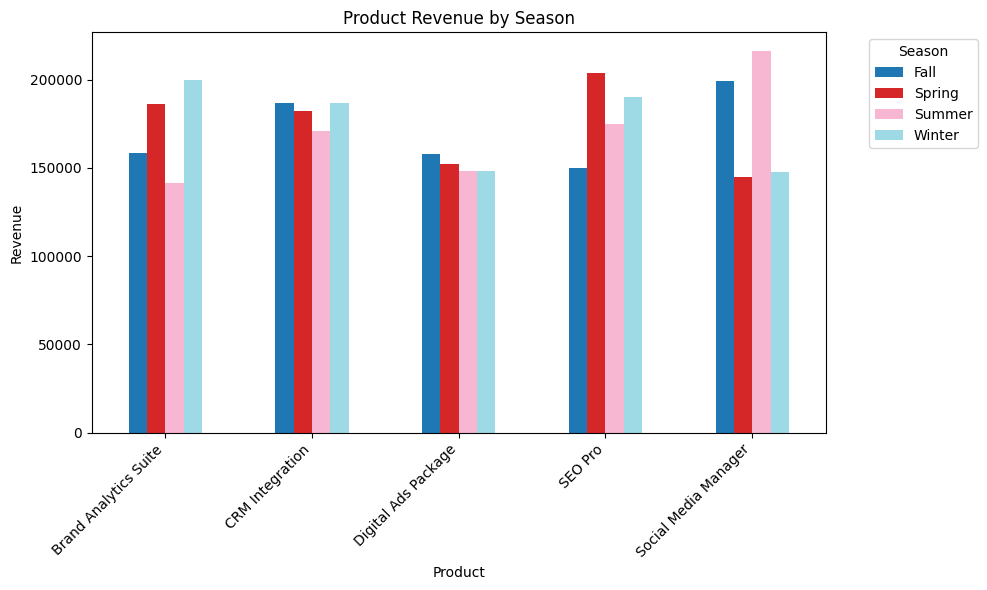

In [207]:
import warnings

plot_data = product_rev.drop('Total', axis=0).drop('Total', axis=1)

warnings.filterwarnings('ignore')
plot_data.plot(kind='bar', figsize=(10, 6), colormap='tab20')
plt.title('Product Revenue by Season')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.legend(title='Season', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [129]:
cp['month_short']=cp['lead_date'].dt.strftime('%b')

In [131]:
cp.groupby('month_short')['lead_id'].count().sort_values(ascending=False)

month_short
May    443
Oct    437
Sep    427
Jul    423
Feb    420
Dec    415
Aug    413
Mar    411
Nov    410
Apr    405
Jan    400
Jun    396
Name: lead_id, dtype: int64

In [227]:
cp.groupby('year')['lead_id'].count()

year
2023    2411
2024    2589
Name: lead_id, dtype: int64

In [225]:
camp=cp.groupby('campaign_name').agg(
    revenue= ('revenue', 'sum'),
    cost_per_lead= ('cost_per_lead', 'sum'),
    Conversions   = ('status', lambda x: (x == 'Converted').sum())
)
camp['cost_per_lead'].sum()

np.float64(234577.27000000002)